In [1]:
# Cell 1 — import
import sys
sys.path.append("..")

import pandas as pd
import matplotlib.pyplot as plt
from src.data.data_cleaning import load_config, project_path
from src.models.baseline_model import time_based_split, naive_forecast, train_sarima, forecast_sarima
from src.models.train_model import evaluate_forecast

config = load_config("config/config.yaml")

In [2]:
df = pd.read_csv(project_path(config["data"]["processed_path"]))
df["date"] = pd.to_datetime(df["date"])
target = config["data"]["target"]

train, test = time_based_split(df, config)
print(f"Train: {train['date'].min()} s.d. {train['date'].max()} ({len(train)} hari)")
print(f"Test: {test['date'].min()} s.d. {test['date'].max()} ({len(test)} hari)")


Train: 2023-01-31 00:00:00 s.d. 2025-10-01 00:00:00 (975 hari)
Test: 2025-10-02 00:00:00 s.d. 2025-12-30 00:00:00 (90 hari)


In [3]:
naive_preds = naive_forecast(train, test, target)
naive_metrics = evaluate_forecast(test[target].values, naive_preds)
print("Naive (seasonal) metrics:", naive_metrics)

Naive (seasonal) metrics: {'mae': 27.31111111111111, 'rmse': np.float64(37.898163983672525), 'mape': np.float64(6.6044977298660354)}


In [4]:
sarima_model = train_sarima(train, target)
sarima_preds = forecast_sarima(sarima_model, steps=len(test))
sarima_metrics = evaluate_forecast(test[target].values, sarima_preds)
print("SARIMA metrics:", sarima_metrics)

SARIMA metrics: {'mae': 37.76462148205622, 'rmse': np.float64(47.10146617036362), 'mape': np.float64(9.016650924478927)}


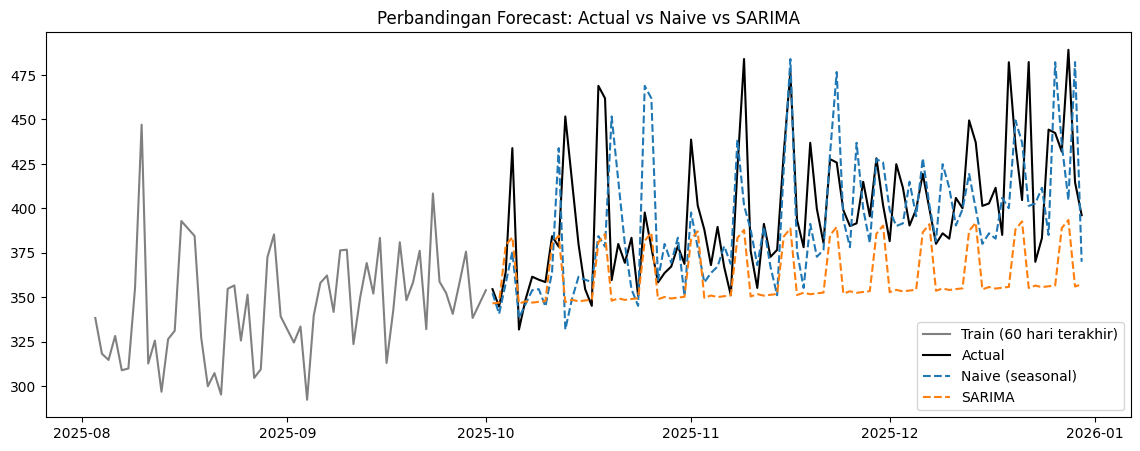

In [5]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(train["date"].iloc[-60:], train[target].iloc[-60:], label="Train (60 hari terakhir)", color="gray")
ax.plot(test["date"], test[target].values, label="Actual", color="black")
ax.plot(test["date"], naive_preds, label="Naive (seasonal)", linestyle="--")
ax.plot(test["date"], sarima_preds, label="SARIMA", linestyle="--")
ax.legend()
ax.set_title("Perbandingan Forecast: Actual vs Naive vs SARIMA")
plt.show()

In [6]:
import pandas as pd
comparison = pd.DataFrame([
    {"model": "naive_seasonal", **naive_metrics},
    {"model": "sarima", **sarima_metrics},
])
comparison

,model,mae,rmse,mape
0,naive_seasonal,27.311111,37.898164,6.604498
1,sarima,37.764621,47.101466,9.016651
